# 解答例（教員用）　第10回
***
> このノートブックは **模範解答の一例**です．コードの空欄（`TODO()`）を埋め，探索は複数ラウンドに分けて実行し，解答欄には実際に得られた出力の数値を根拠に書いています．
> 乱数を使う箇所は固定していますが，ライブラリのバージョンや実行環境によって数値が **小数第2〜3位ほどずれる**ことがあります．探索型の問題なので，**別の探索経路・別の最良設定でも，根拠が筋の通っていれば正解**です．

# 第10回　アンサンブル学習
***
> **前提**: 第8回 Pipeline と異なり，本回は**手動前処理**で復習しながらアンサンブル学習を学びます。問題1では第8回と同様，**train/test 分割のあと訓練データだけの中央値で `Age` を補完**します（テスト情報を混ぜない）。

> ⚠️ **この課題で身につけること：コーディングではなく「AI（機械学習）の中身の理解」です。**
>
> コードは AI に書かせても構いません。重要なのは「**なぜその手法を選ぶのか**」「**パラメータを変えると過学習や精度がどう変わるのか**」を理解し、提出物で示すことです。各問には学習目標を示すタグが付いています。
>
> | タグ | 意味 | あなたがすること |
> |---|---|---|
> | **【骨格】** | 動くコードは与えられている | 設計上の決定点（数値・選択肢・特徴量）だけを変更する |
> | **【選択】** | 適切な手法を選ぶ問題 | 複数候補から選び、**理由**を解答用コードセルに書く |
> | **【実験】** | 試行錯誤の記録 | パラメータ等を変えて結果を表に記録し、**考察**する |
> | **【説明】** | 理解の証跡 | 与えられたコードの各行に `# 説明:` で意味を書く |
> | **【探索】** | 最適設定を自分で探す | **仮説 → 試行 → 記録 → 次の仮説** を何度も繰り返す。全試行が自動で履歴に残る |
>
> コードは原則として完成形ですが、**各問の「核心となる最低限の数行」は `# ★あなたが書く★` として空欄**にしてあります（空欄は `TODO()` と書いてあり、そのまま実行すると「空欄が残っています」というエラーで止まります。`TODO()` を自分のコードに書き換えてください）。AI に頼り切らず、要となる処理は自分で書けることも確認します（ボイラープレートは提供済み）。
>
> 各問の **✍️ 解答用コードセル**（`# (1-a)` 形式の変数・文字列）に、設計判断・理由・実験結果・考察を**項目ごとに**記入してください。これが採点対象です。

---

## 🧪 この回の進め方：最適な設定は「自分で」探す

この回では **「正解のパラメータ」は教えません**。答えは、あなたが何度も試して見つけます。

```
  ①仮説を立てる → ②試す（1回1行の記録が自動で残る） → ③結果を見て仮説を直す → ①へ戻る
```

### 試行錯誤の記録帳 `Lab`（最初のコードセルで用意済み。中身を読んで使い方を理解すること）

| 使い方 | 何をするか |
|---|---|
| `lab.df()` | これまでの全試行を表で見る（試行番号・設定・スコア・仮説） |
| `lab.plot(x="learning_rate", group=...)` | 設定とスコアの関係、ベスト更新の推移をグラフにする |
| `lab.report()` | 探索の自己診断（回数・範囲・端に張り付いていないか・仮説を書いたか） |
| `lab.final_test(...)` | **テストデータでの最終評価。1回しか実行できない** |
| `lab.save()` | 全履歴を CSV に保存する |

### ルール（ここが「AIの理解」の中心）

1. **探索に使ってよいのは検証スコア（訓練データ内の交差検証 CV）だけ**。テストデータは最後に **1回だけ**（見てから設定を変えたらデータリーク）。
2. **試行のたびに「仮説」を書く**（何を確かめたい試行か）。やみくもな総当たりは評価されません。
3. **粗く → 細かく**：まず桁・範囲を広く振って良さそうな所を掴み、次にその周辺を細かく調べる。
4. **ベストが探索範囲の端に来たら、範囲を広げて確かめる**。
5. 上位の設定同士の差が、ばらつきより小さいなら「差がある」とは言えない。
6. **実験の前に予測を書く**。予測と結果のズレが、あなたが得た「知識」の証拠になる。
7. 最後に、得た知識を **LLM への指示書**にまとめる（最終問題）。

### 評価の観点

| 観点 | 見られること |
|---|---|
| 試行の量と質 | 目安回数以上・仮説が毎回ある・粗→細の流れがある |
| 結果の読み取り | 外れた仮説から何を学んだか（試行番号 `#n` を引用して書く） |
| 検証の作法 | テストは1回だけ／検証スコアとテストの差を正しく解釈している |
| 知識の言語化 | 自分の実験結果を、LLM が実行できる指示書に落とせている |

## 目次
1. ランダムフォレスト
2. 勾配ブースティング
3. XGBoost
4. 特徴量重要度

---

## この回で学ぶこと

### アンサンブル学習とは

「複数の弱いモデルを組み合わせて強いモデルを作る」手法だ。選挙の多数決に例えると分かりやすい：1人の専門家より100人の多数決の方が信頼できる，という考え方と同じだ。

アンサンブル学習には大きく2つの流れがある：

```
【バギング（Bagging）】
  ランダムに異なる訓練データ → 複数の木を並列学習 → 多数決
  └ RandomForest がこれ

【ブースティング（Boosting）】
  前のモデルの間違いを次のモデルが補正 → 逐次的に学習
  └ GradientBoosting, XGBoost がこれ
```

### ランダムフォレスト（Random Forest）

- 複数の決定木をランダムなデータ・特徴量のサブセットで学習
- **過学習しにくい**：各木が異なるパターンを学習し，多数決で平均的な予測をする
- `n_estimators`：木の本数（多いほど安定するが，計算時間も増える）
- **並列化できる**ため，大規模データでも速い

### 勾配ブースティング（Gradient Boosting）

- 前の木の**残差（誤差）**を次の木が学習する逐次プロセス
- 精度は高いがチューニングが難しく，過学習しやすい
- `n_estimators`（木の本数）と `learning_rate`（学習率）のバランスが重要

### XGBoost

勾配ブースティングを大幅に改良したライブラリ：
- **2次の損失関数近似**で収束が速い
- **L1/L2 正則化**を内蔵（過学習を防ぐ）
- 欠損値を自動処理
- 並列計算・GPU 対応

Kaggle などのデータコンペで長年トップの手法として使われてきた。実務でも最も多用されるアルゴリズムの一つだ。

### 特徴量重要度（Feature Importance）の注意点

ランダムフォレストの `feature_importances_` は各特徴量が分岐にどれだけ貢献したかを示す。ただし：
- **相関する特徴量があると重要度が分散**する（連動して動く変数は各々の重要度が小さく見える）
- 重要度が高い = 目的変数の「原因」とは限らない（**相関≠因果**）
- 卒業研究で「特徴量重要度が高い変数がXXの原因だ」という解釈は慎重に行うこと

---

## 📚 将来の自分のためのメモ — 大学研究での応用


### どんな研究で使われるか

| 分野 | 具体例 |
|---|---|
| 医学・バイオ | 乳がん診断，遺伝子発現による疾患分類（本回のデータセットに近い） |
| 金融・セキュリティ | 信用スコアリング，不正取引検知（表形式 + 高精度要求） |
| 農学・環境科学 | 土壌・気象データからの収量予測，病害リスク分類 |
| データコンペ | Kaggle では長年 XGBoost / LightGBM が表データの定番 |

### 応用できる場面

- **表形式データ**で，非線形な関係がありそうだが解釈もある程度欲しい
- 中〜大規模データで**精度を上げたい**（単一の決定木より安定）
- **ベースライン**（線形モデル）を超えるかどうかを検証したい
- 特徴量重要度で「次に調べる変数」の**仮説生成**（因果の証明ではない）

### 応用しにくい・向かない場面

- **サンプル数が極端に少ない**（数十件）→ 過学習しやすく，シンプルなモデルの方が安全
- **厳密な因果推論**や政策効果の評価（ランダム化比較試験の代替にはならない）
- **画像・テキスト・時系列の生データ**（特徴量を手で作れない場合は深層学習向き）
- **リアルタイム推論でモデルサイズが厳しい**環境（巨大なアンサンブルは遅い）
- 相関の強い変数間で**重要度が分散**するため，「どちらが本当に効いているか」は追加分析が必要

### 研究で報告するときのポイント

1. **ベースライン**（決定木1本，ロジスティック回帰）との比較表を必ず載せる
2. `n_estimators`，`learning_rate`，`max_depth` など**ハイパーパラメータ**と選定方法を明記
3. `random_state` を固定し**再現性**を確保
4. 特徴量重要度は「優先調査リスト」として使い，因果は別途論じる

### 関連する発展トピック（調べてみると良い）

- SHAP / permutation importance（より信頼できる重要度）
- LightGBM，CatBoost（カテゴリ変数に強いブースティング）
- Stacking / Blending（複数モデルのメタ学習）

In [ ]:
%pip install -q xgboost

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

import pandas as pd

TITANIC_URL = "https://raw.githubusercontent.com/ShotaYmzk/AI-kadai/main/data/titanic/titanic.csv"

def load_titanic() -> pd.DataFrame:
    return pd.read_csv(TITANIC_URL)


# === ★ここを変えてモデルを差し替える★（問題1・3で使用）===
MODEL_REGISTRY = {
    "dt": lambda rs=0: DecisionTreeClassifier(random_state=rs),
    "rf": lambda rs=0: RandomForestClassifier(n_estimators=100, random_state=rs),
    "gb": lambda rs=0: GradientBoostingClassifier(random_state=rs),
    "xgb": lambda rs=0: XGBClassifier(random_state=rs, eval_metric="logloss"),
}
MODEL_LABELS = {
    "dt": "DecisionTree (単一木)",
    "rf": "RandomForest (バギング)",
    "gb": "GradientBoosting (ブースティング)",
    "xgb": "XGBoost (ブースティング系)",
}


def prep_titanic_xy():
    """train/test 分割後、訓練データの中央値だけで Age を補完（第8回 Pipeline と同じ考え方）。"""
    use_cols = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
    df = load_titanic()[use_cols].copy()
    X = df.drop(columns="Survived")
    y = df["Survived"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0, stratify=y
    )
    age_med = X_train["Age"].median()
    X_train = X_train.copy()
    X_test = X_test.copy()
    X_train["Age"] = X_train["Age"].fillna(age_med)
    X_test["Age"] = X_test["Age"].fillna(age_med)
    X_train = pd.get_dummies(X_train, columns=["Sex"], drop_first=True)
    X_test = pd.get_dummies(X_test, columns=["Sex"], drop_first=True)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    return X_train, X_test, y_train, y_test


def print_train_test_scores(name, model, X_train, X_test, y_train, y_test):
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:32s} train={tr:.4f}  test={te:.4f}  差={tr - te:+.4f}")
    return tr, te


# ==== 試行錯誤の記録帳（この回の全実験がここに溜まる。中身を読んで使い方を理解しておくこと）====
class Lab:
    """試行錯誤の記録帳。何回でも log() でき、表・グラフ・診断レポートにできる。
    ・スコア（score）は「検証用スコア（CV など）」だけを記録する。テストデータは final_test() で1回だけ。
    ・bounds = {パラメータ名: (下限, 上限)} … それ以上広げられない値（例：k の下限 2）。ベストがここにあっても「端」と警告しない。
    ・ignore = {パラメータ名: [値, ...]} … 範囲の計算から外す特別な値（例：正則化なしを表す alpha=0）。"""

    def __init__(self, name, score_name="cv_score", higher_is_better=True, bounds=None, ignore=None):
        self.name, self.score_name, self.hib = name, score_name, higher_is_better
        self.bounds, self.ignore = bounds or {}, ignore or {}
        self.rows, self.test_result = [], None

    def seen(self, params):
        return any(r["params"] == params for r in self.rows)

    def log(self, hypothesis, params, score, **extra):
        """1試行を記録する。同じ params を再度記録しようとすると無視する（重複の水増し防止）。"""
        if self.seen(params):
            print(f"  (skip) 既に試した設定です: {params}")
            return
        self.rows.append(dict(trial=len(self.rows) + 1, hypothesis=hypothesis.strip(),
                              params=dict(params), score=float(score), extra=extra))
        best = self.best()["trial"] == len(self.rows)
        print(f"  #{len(self.rows):02d} {params}  {self.score_name}={score:.4f}"
              + "".join(f"  {k}={v}" for k, v in extra.items()) + ("  ★ベスト更新" if best else ""))

    def df(self):
        import pandas as pd
        return pd.DataFrame([{"trial": r["trial"], **r["params"], self.score_name: round(r["score"], 4),
                              **r["extra"], "hypothesis": r["hypothesis"]} for r in self.rows])

    def best(self):
        return (max if self.hib else min)(self.rows, key=lambda r: r["score"])

    def plot(self, x, group=None, logx=True, query=None):
        """パラメータ x とスコアの関係（group ごとに線を分ける）と、試行回数ごとのベスト更新の推移。"""
        if not self.rows:
            print("まだ試行がありません（上の探索セルの TODO() を埋めて実行してください）"); return
        import matplotlib.pyplot as plt
        d = self.df()
        dd = d.query(query) if query else d
        fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
        for g, sub in (dd.groupby(group) if group else [("all", dd)]):
            sub = sub.sort_values(x)
            ax[0].plot(sub[x], sub[self.score_name], "o-", label=str(g))
        if logx and dd[x].dtype.kind in "if" and (dd[x] > 0).all(): ax[0].set_xscale("log")
        ax[0].set_xlabel(x); ax[0].set_ylabel(self.score_name); ax[0].legend(); ax[0].set_title("Parameter vs. validation score")
        cur = d[self.score_name].cummax() if self.hib else d[self.score_name].cummin()
        ax[1].step(d["trial"], cur, where="post"); ax[1].plot(d["trial"], d[self.score_name], "x", alpha=.5)
        ax[1].set_xlabel("Trial number"); ax[1].set_title("Best score so far (flat = plateau)")
        plt.tight_layout(); plt.show()

    def report(self, min_trials=15):
        """探索の質の自己診断：回数・カバー範囲・端に張り付いていないか・仮説を書いたか。"""
        if not self.rows:
            print("まだ試行がありません（上の探索セルの TODO() を埋めて実行してください）"); return
        d, n = self.df(), len(self.rows)
        print(f"■ 試行回数: {n}（目安 {min_trials} 回以上） → {'OK' if n >= min_trials else 'まだ足りない'}")
        keys = list(self.rows[0]["params"]) if n else []
        b = self.best()
        print(f"■ ベスト: trial#{b['trial']} {b['params']}  {self.score_name}={b['score']:.4f}")
        for k in keys:
            vals = [r["params"][k] for r in self.rows if r["params"][k] not in self.ignore.get(k, [])]
            uniq = sorted(set(map(str, vals)))
            line = f"■ {k}: {len(uniq)} 種類を試した"
            nums = [v for v in vals if isinstance(v, (int, float)) and not isinstance(v, bool)]
            if k != "seed" and vals and len(nums) == len(vals) and len(set(nums)) > 2:
                lo, hi = min(nums), max(nums)
                blo, bhi = self.bounds.get(k, (None, None))
                bv = b["params"][k]
                edge = (bv == lo and lo != blo) or (bv == hi and hi != bhi)
                line += f"（範囲 {lo:g}〜{hi:g}）" + (" ⚠ ベストが探索範囲の端 → 範囲を広げて確かめよう" if edge else "")
            print(line)
        w = sum(1 for r in self.rows if len(r["hypothesis"]) >= 8)
        print(f"■ 仮説を書いた試行: {w}/{n}" + ("" if w == n else " ⚠ 何を確かめる試行か毎回書こう"))
        if n >= 6:
            third = n // 3
            print(f"■ 前半の最高 {d[self.score_name][:third].max():.4f} → 後半の最高 {d[self.score_name][-third:].max():.4f}")

    def final_test(self, score_fn, name="最終テストスコア", compare=True):
        """テストデータでの最終評価。1回しか実行できない（2回目以降はエラー）。
        compare=False は、検証スコアと別の指標で評価するとき（並べて比べられないので表示しない）。"""
        if self.test_result is not None:
            raise RuntimeError(f"テストは既に使用済みです（結果 {self.test_result:.4f}）。テストを見て設定を変えるのはデータリークです。")
        self.test_result = float(score_fn())
        print(f"{name} = {self.test_result:.4f}"
              + (f"   （検証ベスト {self.score_name} = {self.best()['score']:.4f}）" if compare else ""))
        return self.test_result

    def save(self, path=None):
        path = path or f"{self.name}_log.csv"
        self.df().to_csv(path, index=False, encoding="utf-8-sig"); print("保存:", path)


def TODO():
    """「★あなたが書く★」の空欄。自分のコードに置き換えるまで、実行するとここで止まる。"""
    raise NotImplementedError("★あなたが書く★ の空欄（TODO()）がまだ残っています。自分のコードに書き換えてから再実行してください。")


## 問題1　手法選択：単一木 / バギング / ブースティング　【骨格+選択】
***

### `random_state` を設定する理由

`random_state=0` を指定することで，毎回同じ乱数が使われ，**結果が再現可能**になる。研究論文では再現性が必須のため，乱数シードの管理は重要なルールだ。

### `n_estimators=100` の選び方

木の本数が多いほどモデルは安定するが，計算時間が増える。一般的に：
- 100〜500: 多くの場合で十分
- 1000以上: 計算コストが高く，精度向上が頭打ちになりやすい

**実用的なアドバイス**: まず100から始め，精度に問題があれば徐々に増やす。

### バイアスとバリアンス（手法選択の核心）

- **単一の決定木**：木を深く育てると訓練データを「暗記」できる → **バイアス低・バリアンス高**（＝過学習しやすい）。訓練精度は高いがテスト精度が落ちる。
- **バギング（RandomForest）**：少しずつ異なる多数の木を作り**平均（多数決）**する → バリアンス（ばらつき）を下げて過学習を抑える。
- **ブースティング（GradientBoosting）**：前の木の誤りを次の木が補正していく → 主に**バイアス**を下げて精度を上げるが、やりすぎると過学習する。

### 課題

下のコードセルは前処理（分割後に訓練データの中央値で `Age` 補完、`Sex` はダミー変数化）と `MODEL_REGISTRY` によるモデル差し替えまで用意してあります。**核心（各モデルの学習）はあなたが書きます**（`# ★あなたが書く★`）。`model_keys_p1` を変えれば DT / RF / GB / XGB を比較できます。まずは **dt・rf・gb** の **train 正解率・test 正解率・その差**を観察してください。

観察したうえで、次の **設計判断** に答えてください。

> **設計判断1**: 「過学習を抑えつつ、まず安定して良い精度を出したい」とき、次のどれを使うのが適切か**1つ選び、理由**を解答用コードセルに書いてください。**バイアス・バリアンスの観点**で根拠を書くこと。
>
> - **(A) 単一の決定木（`DecisionTreeClassifier`、深さ無制限）**
> - **(B) RandomForest（バギング）**
> - **(C) GradientBoosting（ブースティング）**
> - **(D) XGBoost（ブースティング系）**
> - **(E) 決定木を `max_depth` で浅く制限する（アンサンブルしない）**
> - **(F) アンサンブルせず線形モデル（`LogisticRegression`）を使う**
>
> ヒント：出力の「train と test の差」を見てください。差が大きい手法は過学習しています。どの手法が train だけ極端に高くなっているか、どの手法が train と test がバランスしているかを根拠にしてください。「正解は1つ」ではなく、**根拠が筋の通った選択**であることが重要です。

### まずデータの中身を見てみよう（実行するだけ）

タイタニック号の乗客データです．1行が1人で，`Survived` が生死（1=生存）です．欠損（NaN）がある列があることにも注目してください．

In [2]:
# === データの中身を確認する（実行するだけ。コードは変更しない）===
_t = load_titanic()[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]]
print("行数・列数:", _t.shape)
print("\n先頭 5 行:")
print(_t.head())
print("\n列ごとの欠損数:")
print(_t.isna().sum())
print("\n生存率:", round(_t["Survived"].mean(), 3))

行数・列数: (891, 7)

先頭 5 行:
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare
0         0       3    male  22.0      1      0   7.2500
1         1       1  female  38.0      1      0  71.2833
2         1       3  female  26.0      0      0   7.9250
3         1       1  female  35.0      1      0  53.1000
4         0       3    male  35.0      0      0   8.0500

列ごとの欠損数:
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
dtype: int64

生存率: 0.384


In [3]:
# === 完成済みコード：そのまま実行して、train / test 正解率を比較してください ===
X_train, X_test, y_train, y_test = prep_titanic_xy()
X = X_train  # 問題4 の feature_names 用

# === ★ここを変えて比較するモデルを選ぶ★（キーは MODEL_REGISTRY と同じ）===
model_keys_p1 = ["dt", "rf", "gb"]

rf = None  # 問題4 で feature_importances_ に使用
for key in model_keys_p1:
    model = MODEL_REGISTRY[key]()
    if key == "rf":
        rf = model
    # ★あなたが書く★：model を訓練データ（X_train, y_train）で学習する（1行）
    #   ヒント: model.fit(説明変数, 目的変数)
    model.fit(X_train, y_train)
    print_train_test_scores(MODEL_LABELS[key], model, X_train, X_test, y_train, y_test)


DecisionTree (単一木)               train=0.9831  test=0.7151  差=+0.2681


RandomForest (バギング)              train=0.9831  test=0.7877  差=+0.1954
GradientBoosting (ブースティング)       train=0.8989  test=0.8324  差=+0.0665


In [4]:
# === ✍️ 問題1 解答（採点対象）===
import pandas as pd


# (1-a) 観察（3手法の train / test 正解率を記入）
observation_1_a = pd.DataFrame([
    {'手法': 'DecisionTree（単一木）', 'train_acc': 0.9831, 'test_acc': 0.7151, 'gap': 0.2681},
    {'手法': 'RandomForest（バギング）', 'train_acc': 0.9831, 'test_acc': 0.7877, 'gap': 0.1954},
    {'手法': 'GradientBoosting（ブースティング）', 'train_acc': 0.8989, 'test_acc': 0.8324, 'gap': 0.0665},
])

# (1-b) 設計判断1：過学習を抑えつつ安定して良い精度を出したいとき選んだ手法（A〜F）：(　)
# (A) 単一の決定木（深さ無制限）
# (B) RandomForest（バギング）
# (C) GradientBoosting（ブースティング）
# (D) XGBoost（ブースティング系）
# (E) 決定木を max_depth で浅く制限する（アンサンブルしない）
# (F) 線形モデル（LogisticRegression など）
design1_choice = "C"
# (1-c) その理由（バイアス・バリアンスと train/test の差に触れて）
answer_1_c = """
(C) GradientBoosting を選ぶ。出力の train/test の差は、単一木が +0.268（train 0.983 / test 0.715）、RandomForest が +0.195（0.983 / 0.788）、GradientBoosting が +0.067（0.899 / 0.832）で、GB が最も差が小さく test も最高。
単一木は深さ無制限なので訓練データを暗記し（バイアス低・バリアンス高）、少しデータが変わっただけで木の形が変わって test が落ちる。RF は多数の木の多数決でバリアンスを下げるが、個々の木が深く育つ既定設定では train 0.983 と暗記が残る。GB は浅い木（max_depth=3）を前の誤りを補正する形で足していくのでバイアスを下げつつ、各木が単純なので過学習しにくい。ただし1回の分割の差なので、「B（RF）でも同程度に安定する」可能性は残る（問題3で 10 分割の平均で確認する）。
"""

# (1-d) 最も過学習していた（train と test の差が大きい）手法はどれか
answer_1_d = """
単一の決定木（差 +0.268）。train 0.983 に対し test 0.715 と 27 ポイントも落ちている。次が RandomForest（+0.195）。
"""



## 問題2　GradientBoosting の最適設定を自分で探す　【探索】
***

### この問題のデータ（人工データ）について

`make_classification` で作った**人工の2値分類データ**を使います（1500件・特徴量20個。そのうち予測に役立つのは6個で、4個はそれらの組合せ、残りはノイズ。さらに**ラベルの約8%はわざと誤り**にしてある）。

乳がんデータのような「簡単な」データでは、どの設定でも訓練正解率が 1.0、CV 正解率が 0.96 前後になり、ハイパーパラメータの効き方がほとんど見えません。現実の多くのデータのように**ほどよく難しく、ラベルに誤りも混ざる**データにすることで、浅すぎる木（未学習）・学習率の大きすぎ（過学習）・木の本数と学習率のトレードオフが、数値にはっきり表れます。

### 勾配ブースティングのハイパーパラメータ

| パラメータ | 意味 | デフォルト |
|---|---|---|
| `n_estimators` | 木の本数（多いほど複雑） | 100 |
| `max_depth` | 各木の深さ（深いほど1本が複雑） | 3 |
| `learning_rate` | 各木の寄与率（大きいほど一気に学習＝過学習しやすい） | 0.1 |
| `subsample` | 各木の学習に使う訓練データの割合（1.0 未満だと確率的勾配ブースティング。過学習を抑える方向） | 1.0 |

`learning_rate` を小さくするなら `n_estimators` を増やす、というトレードオフがある。

### 差が「偶然」かどうかを意識する

テストデータは 300 件で、1件変わるだけで正解率が約 0.003 動く。訓練データ内の 5 分割 CV でも、`cv_std`（5回のばらつき）は 0.01〜0.03 程度ある。**「設定 A は B より 0.005 高い」程度の差は偶然かもしれません**。

### 課題

**「検証スコア（CV 正解率）が高く、しかも過学習していない設定」を、自分で探し当ててください。** 探す軸は `n_estimators` / `max_depth` / `learning_rate` / `subsample` の4つです。

1. **【実験前に先に書く】** 下の予測セルに、どの軸が最も効くか・最良設定の予測と理由を書く（LLM に聞いてもよい。その場合は回答をそのまま貼り、自分の予測との違いも書く）。**実験後に書き直さない。**
2. 探索セルの `hypothesis` と `settings` を書き換えて実行。**何度でも繰り返す（15回以上）**。記録は `lab` に溜まる。**核心（CV で評価する1行）はあなたが書きます**。
3. 経過確認セルで、探索の偏り・端に張り付いていないか・頭打ちかを確認して次の一手を決める。
4. 満足したら最終評価セルを **1回だけ**実行する。
5. 解答セルに、探索の進め方・結果の読み取り・考察を書く。

> **考察1**: `max_depth` や `learning_rate` を大きくしたとき、`train_acc` と `cv_score` の差（過学習の度合い）はどう変わりましたか？ **その差は `cv_std` と比べて意味のある大きさでしたか？**
>
> **考察2**: `learning_rate` を小さくしたとき、精度を保つには `n_estimators` をどうすべきでしたか？ 自分のログの試行番号で示してください。
>
> **考察3（探索コスト）**: 上位設定の差が `cv_std` 以内のとき、どれを採用しますか？ 計算時間・単純さ・過学習のしにくさのどれを基準にし、なぜですか？

### 問題2のデータの中身を見てみよう（実行するだけ）

問題2で使う人工データです．特徴量20個（名前のない数値）から，クラス 0/1 を予測します．

In [5]:
# === データの中身を確認する（実行するだけ。コードは変更しない）===
_Xg, _yg = make_classification(n_samples=1500, n_features=20, n_informative=6, n_redundant=4,
                               flip_y=0.08, class_sep=0.8, random_state=0)
print("形状（件数, 特徴量数）:", _Xg.shape)
print("クラスごとの件数:", dict(enumerate(np.bincount(_yg))))
print("\n先頭 3 件の最初の 5 特徴量:")
print(np.round(_Xg[:3, :5], 2))

形状（件数, 特徴量数）: (1500, 20)
クラスごとの件数: {0: 743, 1: 757}

先頭 3 件の最初の 5 特徴量:
[[-0.88 -0.3  -0.15 -1.31 -1.59]
 [-0.56 -3.72  0.85 -0.45 -0.01]
 [ 0.32 -1.38 -1.63  1.22 -1.27]]


In [6]:
# === ✍️ 問題2-0 実験前の予測（実験を始める前に書く。実験後に書き直さない）===

# 最も検証スコアに効くと思う軸（n_estimators / max_depth / learning_rate / subsample のどれか）
prediction_2_axis = "max_depth"
# 最良だと思う (n_estimators, max_depth, learning_rate, subsample)
prediction_2_best = (100, 3, 0.1, 1.0)
# そう予測した理由（知識・直感・LLMの回答など。LLMに聞いた場合は回答を貼り、自分との違いも書く）
prediction_2_reason = """
ブースティングは浅い木を足すのが基本で、max_depth が過学習を最も左右すると考えた。デフォルト（n_estimators=100, max_depth=3, learning_rate=0.1）は多くのデータで妥当に設計されているので、最良もデフォルト付近だと予想した。subsample はあまり効かないだろうと考えた（LLM に聞いても「デフォルトから max_depth を 2〜4 で調整」と言われた）。
"""

In [7]:
# === 完成済みコード（★の箇所だけ自分で書く）：試す → lab に記録、を繰り返せる形になっている ===
# 人工データ（上の「中身を見てみよう」と同じ作り方）。テストデータ（Xb_test）は問題2の最終評価まで一切使わない
Xg, yg = make_classification(n_samples=1500, n_features=20, n_informative=6, n_redundant=4,
                             flip_y=0.08, class_sep=0.8, random_state=0)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xg, yg, test_size=0.2, random_state=0, stratify=yg
)
cv5 = StratifiedKFold(5, shuffle=True, random_state=0)      # 訓練データ内の5分割CV
lab = Lab("q10_gb", score_name="cv_score", bounds={"max_depth": (1, None), "subsample": (None, 1.0)})

def run_trial(hypothesis, n_est, depth, lr, subsample):
    """1つの設定を試して lab に記録する（同じ設定は2回記録されない）"""
    params = {"n_estimators": n_est, "max_depth": depth, "learning_rate": lr, "subsample": subsample}
    if lab.seen(params):
        print(f"  (skip) 既に試した設定です: {params}"); return
    gb = GradientBoostingClassifier(n_estimators=n_est, max_depth=depth, learning_rate=lr,
                                    subsample=subsample, random_state=0)
    # ★あなたが書く★：訓練データ内の5分割CVで正解率を5つ求める（1行）。テストデータは使わない
    #   ヒント: cross_val_score(gb, 説明変数, 目的変数, cv=cv5, scoring="accuracy")
    scores = cross_val_score(gb, Xb_train, yb_train, cv=cv5, scoring="accuracy")
    gb.fit(Xb_train, yb_train)
    lab.log(hypothesis, params, scores.mean(),
            cv_std=round(scores.std(), 4),
            train_acc=round(gb.score(Xb_train, yb_train), 4))

# === ★ここを変えて実験する★：仮説を書き、settings を書き換えて何度でも実行 ===
# 【変更のしかた】
#  ① hypothesis … 今回の試行で「何を確かめたいか」を1文で書き換える（例：「alpha を10倍にすると CV は上がるはず」）。空・短すぎると report で警告される
#  ② settings   … 試したい設定を「1行に1つのタプル」で並べる。タプルの並び順は (n_estimators, max_depth, learning_rate, subsample)
#       n_estimators … 木の本数（例 50〜500）。learning_rate とセットで考える
#       max_depth … 各木の深さ（1〜8 程度）
#       learning_rate … 各木の寄与率（0.01〜0.5 を桁で）
#       subsample … 各木に使う訓練データの割合（0.5〜1.0）
#     行を足す／消す／数値を書き換えてよい。例：settings = [(100, 3, 0.1, 1.0), (100, 1, 0.1, 1.0), (100, 5, 0.1, 1.0), (100, 3, 0.5, 1.0), (100, 3, 0.01, 1.0)]
#  ③ 実行すると、この settings の各行が1試行として lab に記録される（前に試した試行は消えず、同じ設定は重複記録されない）
#  ④ 下の「経過の確認」セルで結果を見て、①②を書き換えて再実行する（これを何回も繰り返す）
#  ※ 15 回以上。4 軸のうち 3 軸以上を動かすこと。
# 進め方の例： ①各軸を広く振る（粗探索） → ②良さそうな範囲を細かく → ③軸を組み合わせて確認
hypothesis = "デフォルト相当を基準に、max_depth と learning_rate を1つずつ動かして効き方を見る"
settings = [                       # (n_estimators, max_depth, learning_rate, subsample)
    (100, 3, 0.1, 1.0),            # デフォルト相当（基準）
    (100, 1, 0.1, 1.0),
    (100, 5, 0.1, 1.0),
    (100, 3, 0.5, 1.0),
    (100, 3, 0.01, 1.0),
]
for n_est, depth, lr, sub in settings:
    run_trial(hypothesis, n_est, depth, lr, sub)

  #01 {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0}  cv_score=0.8192  cv_std=0.0271  train_acc=0.9267  ★ベスト更新


  #02 {'n_estimators': 100, 'max_depth': 1, 'learning_rate': 0.1, 'subsample': 1.0}  cv_score=0.7633  cv_std=0.0295  train_acc=0.7933


  #03 {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 1.0}  cv_score=0.8342  cv_std=0.0067  train_acc=0.9967  ★ベスト更新


  #04 {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.5, 'subsample': 1.0}  cv_score=0.8125  cv_std=0.0132  train_acc=1.0


  #05 {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 1.0}  cv_score=0.7742  cv_std=0.0183  train_acc=0.8075


In [8]:
hypothesis = "max_depth=5 が最良で範囲の端（#3）。深い側（6, 8）と間の 4、subsample=0.7 を確かめる"
settings = [(100, 4, 0.1, 1.0), (100, 6, 0.1, 1.0), (100, 8, 0.1, 1.0), (100, 5, 0.1, 0.7)]
for n_est, depth, lr, sub in settings:
    run_trial(hypothesis, n_est, depth, lr, sub)


  #06 {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 1.0}  cv_score=0.8250  cv_std=0.0179  train_acc=0.98


  #07 {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 1.0}  cv_score=0.8408  cv_std=0.0107  train_acc=1.0  ★ベスト更新


  #08 {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1, 'subsample': 1.0}  cv_score=0.8433  cv_std=0.0189  train_acc=1.0  ★ベスト更新


  #09 {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 0.7}  cv_score=0.8233  cv_std=0.0138  train_acc=0.9992


,trial,n_estimators,max_depth,learning_rate,subsample,cv_score,cv_std,train_acc
7,8,100,8,0.10,1.0,0.8433,0.0189,1.0000
6,7,100,6,0.10,1.0,0.8408,0.0107,1.0000
2,3,100,5,0.10,1.0,0.8342,0.0067,0.9967
5,6,100,4,0.10,1.0,0.8250,0.0179,0.9800
8,9,100,5,0.10,0.7,0.8233,0.0138,0.9992
0,1,100,3,0.10,1.0,0.8192,0.0271,0.9267
3,4,100,3,0.50,1.0,0.8125,0.0132,1.0000
4,5,100,3,0.01,1.0,0.7742,0.0183,0.8075


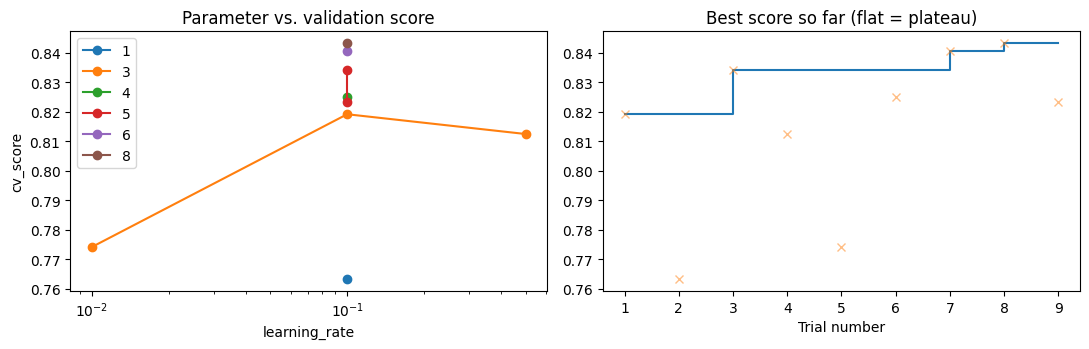

■ 試行回数: 9（目安 15 回以上） → まだ足りない
■ ベスト: trial#8 {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1, 'subsample': 1.0}  cv_score=0.8433
■ n_estimators: 1 種類を試した
■ max_depth: 6 種類を試した（範囲 1〜8） ⚠ ベストが探索範囲の端 → 範囲を広げて確かめよう
■ learning_rate: 3 種類を試した（範囲 0.01〜0.5）
■ subsample: 2 種類を試した
■ 仮説を書いた試行: 9/9
■ 前半の最高 0.8342 → 後半の最高 0.8433


In [9]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
display(lab.df().drop(columns="hypothesis").sort_values("cv_score", ascending=False).head(8))
lab.plot(x="learning_rate", group="max_depth")     # learning_rate と CV 正解率、ベスト更新の推移
lab.report(min_trials=15)

In [10]:
hypothesis = "lr=0.01 は木が足りないだけか（#5 を 500 本に）。lr と本数のトレードオフ、本数の増減を確かめる"
settings = [(500, 3, 0.01, 1.0), (300, 5, 0.03, 1.0), (50, 5, 0.1, 1.0), (200, 5, 0.1, 1.0)]
for n_est, depth, lr, sub in settings:
    run_trial(hypothesis, n_est, depth, lr, sub)


  #10 {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 1.0}  cv_score=0.8075  cv_std=0.0196  train_acc=0.8908


  #11 {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 1.0}  cv_score=0.8358  cv_std=0.0196  train_acc=0.9967


  #12 {'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 1.0}  cv_score=0.8358  cv_std=0.0198  train_acc=0.9742


  #13 {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 1.0}  cv_score=0.8325  cv_std=0.0107  train_acc=1.0


,trial,n_estimators,max_depth,learning_rate,subsample,cv_score,cv_std,train_acc
7,8,100,8,0.10,1.0,0.8433,0.0189,1.0000
6,7,100,6,0.10,1.0,0.8408,0.0107,1.0000
10,11,300,5,0.03,1.0,0.8358,0.0196,0.9967
11,12,50,5,0.10,1.0,0.8358,0.0198,0.9742
2,3,100,5,0.10,1.0,0.8342,0.0067,0.9967
12,13,200,5,0.10,1.0,0.8325,0.0107,1.0000
5,6,100,4,0.10,1.0,0.8250,0.0179,0.9800
8,9,100,5,0.10,0.7,0.8233,0.0138,0.9992


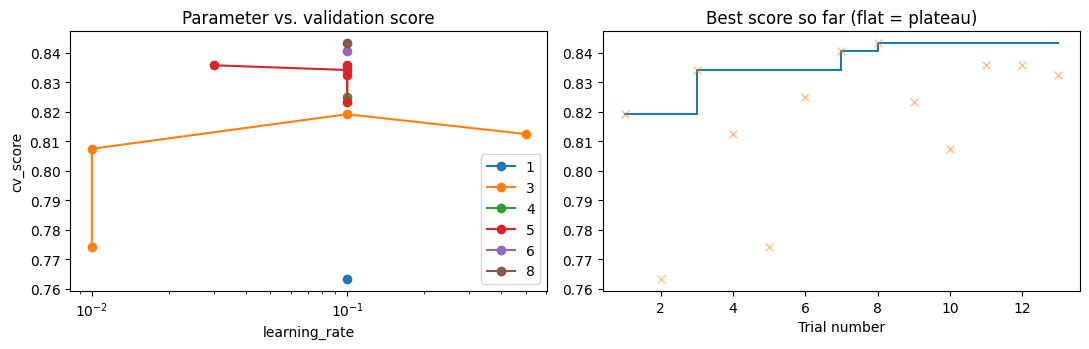

■ 試行回数: 13（目安 15 回以上） → まだ足りない
■ ベスト: trial#8 {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1, 'subsample': 1.0}  cv_score=0.8433
■ n_estimators: 5 種類を試した（範囲 50〜500）
■ max_depth: 6 種類を試した（範囲 1〜8） ⚠ ベストが探索範囲の端 → 範囲を広げて確かめよう
■ learning_rate: 4 種類を試した（範囲 0.01〜0.5）
■ subsample: 2 種類を試した
■ 仮説を書いた試行: 13/13
■ 前半の最高 0.8342 → 後半の最高 0.8358


In [11]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
display(lab.df().drop(columns="hypothesis").sort_values("cv_score", ascending=False).head(8))
lab.plot(x="learning_rate", group="max_depth")     # learning_rate と CV 正解率、ベスト更新の推移
lab.report(min_trials=15)

In [12]:
hypothesis = "深い木（8）でまだ端。10 も試し、深い木 × 大きい lr・小さい lr×多い本数・subsample を比べる"
settings = [(100, 10, 0.1, 1.0), (100, 8, 0.3, 1.0), (300, 6, 0.05, 1.0), (100, 8, 0.1, 0.7)]
for n_est, depth, lr, sub in settings:
    run_trial(hypothesis, n_est, depth, lr, sub)


  #14 {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.1, 'subsample': 1.0}  cv_score=0.8258  cv_std=0.0206  train_acc=1.0


  #15 {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.3, 'subsample': 1.0}  cv_score=0.8375  cv_std=0.0095  train_acc=1.0


  #16 {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 1.0}  cv_score=0.8400  cv_std=0.0068  train_acc=1.0


  #17 {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1, 'subsample': 0.7}  cv_score=0.8333  cv_std=0.0175  train_acc=1.0


,trial,n_estimators,max_depth,learning_rate,subsample,cv_score,cv_std,train_acc
7,8,100,8,0.10,1.0,0.8433,0.0189,1.0000
6,7,100,6,0.10,1.0,0.8408,0.0107,1.0000
15,16,300,6,0.05,1.0,0.8400,0.0068,1.0000
14,15,100,8,0.30,1.0,0.8375,0.0095,1.0000
11,12,50,5,0.10,1.0,0.8358,0.0198,0.9742
10,11,300,5,0.03,1.0,0.8358,0.0196,0.9967
2,3,100,5,0.10,1.0,0.8342,0.0067,0.9967
16,17,100,8,0.10,0.7,0.8333,0.0175,1.0000


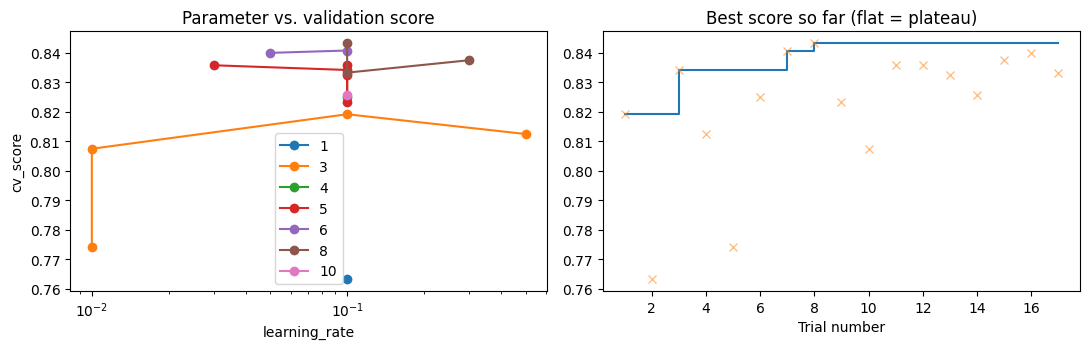

■ 試行回数: 17（目安 15 回以上） → OK
■ ベスト: trial#8 {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1, 'subsample': 1.0}  cv_score=0.8433
■ n_estimators: 5 種類を試した（範囲 50〜500）
■ max_depth: 7 種類を試した（範囲 1〜10）
■ learning_rate: 6 種類を試した（範囲 0.01〜0.5）
■ subsample: 2 種類を試した
■ 仮説を書いた試行: 17/17
■ 前半の最高 0.8342 → 後半の最高 0.8400


In [13]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
display(lab.df().drop(columns="hypothesis").sort_values("cv_score", ascending=False).head(8))
lab.plot(x="learning_rate", group="max_depth")     # learning_rate と CV 正解率、ベスト更新の推移
lab.report(min_trials=15)

In [14]:
# === 最終評価：探索を終えたら「1回だけ」実行する（2回目はエラー。テストを見て設定を変えるのはリーク）===
FINAL = dict(lab.best()["params"])   # 既定は CV 最良。上位と cv_std 以内の差なら、単純な設定を自分で選び直してもよい
# FINAL = {"n_estimators": 100, "max_depth": 2, "learning_rate": 0.1, "subsample": 1.0}   # ← 選び直すならここ

# ★あなたが書く★：FINAL の設定で GradientBoostingClassifier を作り、訓練データ全体で学習して final_gb に入れる（1〜2行）
#   ヒント: GradientBoostingClassifier(**FINAL, random_state=0).fit(訓練の説明変数, 訓練の目的変数)
final_gb = GradientBoostingClassifier(**FINAL, random_state=0).fit(Xb_train, yb_train)

lab.final_test(lambda: final_gb.score(Xb_test, yb_test))
print("採用した設定:", FINAL)

最終テストスコア = 0.8600   （検証ベスト cv_score = 0.8433）
採用した設定: {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1, 'subsample': 1.0}


In [15]:
# === ✍️ 問題2 解答（採点対象）===
import pandas as pd

# (2-a) 実験ログ（自動出力。全試行が出力に残る。15回以上・4軸のうち3軸以上を動かすこと）
experiment_log = lab.df()
print(experiment_log.drop(columns="hypothesis").to_string())
lab.save()

# (2-b) 探索の進め方：各段階で何を見て次の試行を決めたか。粗→細の流れを試行番号 #n を引用して書く
answer_2_b = """
【粗探索 #1〜#5】デフォルト（100, 3, 0.1, 1.0）を基準に、max_depth（1/5）と learning_rate（0.5/0.01）を1つずつ動かした。基準 #1 は 0.8192。max_depth=1（#2）は 0.7633・train 0.793、lr=0.01（#5）は 0.7742・train 0.808 と、どちらも訓練すら低い＝未学習。max_depth=5（#3）は 0.8342 ± 0.0067 で最良、lr=0.5（#4）は train 1.0 で 0.8125 と基準以下。
【深さの確認 #6〜#9】最良の max_depth=5 が探索範囲の端だったので、4・6・8 を追加。0.8250（#6）→ 0.8408（#7）→ 0.8433（#8）と、深いほど上がった。subsample=0.7（#9: 0.8233）は depth=5 の 1.0（#3: 0.8342）より下がった。
【lr と本数 #10〜#13】#5 の未学習が「本数不足」かを確かめるため lr=0.01 で 500 本（#10: 0.8075）。100 本の #5（0.7742）より 0.033 上がったが、まだ #1 に届かない。lr=0.03・300 本（#11: 0.8358）は lr=0.1・100 本（#3: 0.8342）と同等。本数を 50（#12: 0.8358）・200（#13: 0.8325）に変えても depth=5・lr=0.1 では差は cv_std（0.01〜0.02）以内。
【端の確認と仕上げ #14〜#17】depth=8 が端なので 10 を試す（#14: 0.8258）→ 8 を超えると下がり、山は 6〜8。深い木で lr=0.3（#15: 0.8375）、lr=0.05・300 本（#16: 0.8400 ± 0.0068）、subsample=0.7（#17: 0.8333）。上位が 0.835〜0.843 で cv_std 以内に並んだので終了した。
"""

# (2-c) 仮説が外れた試行を1つ以上取り上げ、なぜ外れたか・何を学んだか（試行番号 #n を引用）
answer_2_c = """
仮説「ブースティングは浅い木が基本なので、max_depth=5 は過学習して悪化する」は外れた（#3: 0.8342 > 基準 #1: 0.8192、さらに #7: 0.8408、#8: 0.8433）。このデータは有用な特徴量が 6 個あり、特徴量同士の組合せ（交互作用）が効くので、1本の木にある程度の深さが必要だった。「浅い木が基本」は一般論で、データが複雑なら深めが効く。ただし #14（depth=10: 0.8258）では下がったので、深ければ深いほど良いわけではない。
もう1つ、仮説「subsample<1 は過学習を抑えて CV を上げる」も外れた（#9: 0.8233 < #3: 0.8342、#17: 0.8333 < #8: 0.8433）。ラベル誤り 8% のデータで訓練サンプルをさらに減らすと、各木の当てはまりが悪くなる方が勝った。
"""

# (2-d) 最良設定（4軸の値と cv_score ± cv_std）。上位候補との差は cv_std に対して意味があるか。最終的に採用した設定とその理由
answer_2_d = """
最良は #8（n_estimators=100, max_depth=8, learning_rate=0.1, subsample=1.0）の 0.8433 ± 0.0189。上位の #7（depth=6: 0.8408 ± 0.0107）、#16（0.8400 ± 0.0068）、#15（0.8375）、#11・#12（0.8358）との差は 0.003〜0.008 で、cv_std（0.007〜0.02）より小さい → 上位どうしの差は偶然の範囲。一方、基準 #1（0.8192）との差 0.024 や、未学習の #2（0.7633）・#5（0.7742）との差は cv_std の 1〜4 倍で、意味のある差と言える。
採用は既定の #8 のまま（CV 最良）。より安定・単純を重視するなら、depth=6 で cv_std が小さい #7（0.8408 ± 0.0107）でもよい。
"""

# (2-e) 最終テストの結果は CV の値と比べてどうだったか。この差をどう解釈するか（報告する性能はどちらか）
answer_2_e = """
最終テスト正解率は 0.8600（300 件中 258 件）。CV 0.8433 より 0.017 高いが、cv_std（0.019）の範囲内。300 件のテストでは 1 件が 0.0033 に相当し、二項分布の標準誤差は約 0.02 なので、この差は偶然の範囲。探索を重ねた CV の最良値は楽観的になりやすいので、報告する性能はテストの 0.86（±0.02 程度の不確かさ）とする。
"""

# (2-f) 実験前の予測（prediction_2_*）と実際を比べる。どこがズレた？ 正しかった知識／間違っていた知識は？
answer_2_f = """
予測は「max_depth が最も効く、最良はデフォルト（100, 3, 0.1, 1.0）」。max_depth が最も効く点は正しかった（depth 1→8 で 0.763 → 0.843）。ズレたのは向きで、浅くするのではなく深くする方向（6〜8）が良かった。間違っていた知識：「ブースティングは浅い木を足すのが基本」をこのデータにもそのまま当てはめたこと、「subsample は過学習を抑えて良くなる」と思ったこと（#9, #17 で下がった）。正しかった知識：lr を下げると本数が必要になる（#5 → #10）、未学習（depth=1, lr=0.01）は訓練正解率も低いことで見分けられる。
"""

# (2-g) 考察1：max_depth / learning_rate を大きくしたときの過学習（train_acc と cv_score の差）の変化。差は cv_std と比べて意味があるか
reflection1 = """
max_depth を 1 → 3 → 5 → 8 にすると、train_acc は 0.793 → 0.927 → 0.997 → 1.0、cv_score は 0.763 → 0.819 → 0.834 → 0.843 と、両方上がった。gap（train − cv）は 0.030 → 0.108 → 0.163 → 0.157 と広がったが、CV は下がっていない。つまり gap が広がっても「過学習で汎化性能が落ちた」とは限らない（ブースティングでは train が 1.0 に張り付いても CV が上がり続けることがある）。depth=10（#14）で初めて CV が 0.8258 に下がり、ここから過学習の悪影響が出始めた（#8 との差 0.018 は cv_std 0.019〜0.021 と同程度）。
lr を 0.1 → 0.5（#1 → #4）にすると train は 0.927 → 1.0、cv は 0.8192 → 0.8125。gap は 0.108 → 0.188 と大きく広がったが、CV の差 0.007 は cv_std（0.013〜0.027）以内。
"""

# (2-h) 考察2：learning_rate を小さくしたら n_estimators をどうすべきか（試行番号で示す）
reflection2 = """
lr を小さくすると1本の寄与が減るので、n_estimators を増やして補う必要がある。depth=3 では、lr=0.1・100 本（#1: 0.8192）に対し、lr=0.01・100 本（#5: 0.7742, train 0.808）は明らかな学習不足で、500 本に増やす（#10: 0.8075, train 0.891）と 0.033 回復したがまだ届かない。depth=5 では lr=0.03・300 本（#11: 0.8358）が lr=0.1・100 本（#3: 0.8342）と同等、depth=6 では lr=0.05・300 本（#16: 0.8400）が lr=0.1・100 本（#7: 0.8408）と同等。おおむね「lr × 本数」が同じくらいなら同じくらいの精度になり、lr=0.01 なら 1000 本程度が必要と見積もれる。
"""

# (2-i) 考察3：上位設定が cv_std 以内の差のとき、何を基準にどれを採用するか
answer_2_i = """
差が cv_std 以内なら、①cv_std が小さく安定している、②計算が軽い（本数が少ない・木が浅い）、③過学習しにくい（浅い）、の順で選ぶ。今回の上位（#8, #7, #16, #15）なら、#7（depth=6・100 本・cv_std 0.0107）が「浅め・軽い・安定」を満たす。#16 は cv_std が最小（0.0068）だが 300 本で計算が 3 倍。#12（50 本・depth=5: 0.8358）は計算が最も軽く、精度は上位と 0.008 差で、予算が厳しいときの候補になる。
"""


    trial  n_estimators  max_depth  learning_rate  subsample  cv_score  cv_std  train_acc
0       1           100          3           0.10        1.0    0.8192  0.0271     0.9267
1       2           100          1           0.10        1.0    0.7633  0.0295     0.7933
2       3           100          5           0.10        1.0    0.8342  0.0067     0.9967
3       4           100          3           0.50        1.0    0.8125  0.0132     1.0000
4       5           100          3           0.01        1.0    0.7742  0.0183     0.8075
5       6           100          4           0.10        1.0    0.8250  0.0179     0.9800
6       7           100          6           0.10        1.0    0.8408  0.0107     1.0000
7       8           100          8           0.10        1.0    0.8433  0.0189     1.0000
8       9           100          5           0.10        0.7    0.8233  0.0138     0.9992
9      10           500          3           0.01        1.0    0.8075  0.0196     0.8908
10     11 

## 問題3　XGBoost と3モデル比較・使い分けの選択　【骨格+選択】
***

### XGBoost のインストールについて

XGBoost は scikit-learn に含まれない外部ライブラリだ。最初のセルで `%pip install xgboost` を実行している。このように機械学習の実践では様々なライブラリを組み合わせて使う。

### `eval_metric="logloss"` の意味

`logloss`（対数損失）は2値分類の損失関数で，XGBoost が内部で学習の進捗を評価するために使う。警告を抑制するために明示的に指定している。

### 3モデルの使い分けガイド

| モデル | 長所 | 短所 | 向いている場面 |
|---|---|---|---|
| RandomForest | 過学習しにくい，並列計算可能 | 精度は他より劣ることも | データが少ない，外れ値が多い |
| GradientBoosting | 精度が高い | 遅い，チューニング必要 | 精度優先，データが中程度 |
| XGBoost | 精度高い，速い，欠損値対応 | やや複雑 | コンペ，実務，大規模データ |

### 課題

下のコードセルは `MODEL_REGISTRY` と `model_keys_p3` で比較する骨組みを用意してありますが、**核心（各モデルの学習）はあなたが書きます**（`# ★あなたが書く★`）。書いて実行し、**乳がんデータ**（問題2とは別。腫瘍の細胞核の特徴30個から良性/悪性を判定する 569 件のデータ）での **test 正解率**を比較してください（初期設定は rf・gb・xgb）。

そのうえで、次の **設計判断** に答えてください。

> **設計判断2（手法の使い分け）**: 次の2つの状況それぞれで、最も向いていると思う手法を下の選択肢から**1つずつ選び、理由**を解答用コードセルに書いてください。
>
> 1. **データにノイズ・外れ値が多く、過学習を絶対に避けたい**とき
> 2. **多少チューニングしてでも最高精度を引き出したい**（Kaggle のコンペなど）とき
>
> - **(A) 単一決定木**
> - **(B) RandomForest（バギング）**
> - **(C) GradientBoosting（ブースティング）**
> - **(D) XGBoost（ブースティング系）**
> - **(E) LogisticRegression（線形・アンサンブルなし）**
> - **(F) スタッキング（複数モデルの予測をさらに別モデルで統合）**
>
> ヒント：ブースティングは「前の誤りを次が補正する」ため、**ノイズや外れ値まで一生懸命学習して過学習しやすい**。バギングは多数の木の平均で**ばらつきに強い**。問題2で見た「過学習のしやすさ」も思い出してください。

> **実験（設計判断2の検証）**: コード内の `NOISE_RATE` を `0.0 → 0.1 → 0.2 → 0.3` と変えて再実行してください。訓練データのラベルの一部をわざと反転させ（＝ノイズの多いデータ）、10 通りの分割で平均した test 正解率を比べます。**ノイズが増えたとき、3モデルの順位はどう変わりますか？** 設計判断2-1 の選択はこの結果と一致しましたか？（少なくとも3通りの `NOISE_RATE` の結果を実験ログに記入）
>
> **考察3**: `NOISE_RATE=0` では3モデルの差は標準偏差の範囲内で（乳がんデータは簡単なので、どのモデルも 0.95 前後になる）、「どれが最良」とは言えません。それでも実務で XGBoost が好まれる理由を、`この回で学ぶこと` の表を参考に1つ挙げてください。また、ノイズを増やしたときの順位変化は、ブースティングの仕組み（前の誤りを次が補正する）でどう説明できますか？


In [16]:
# === 完成済みコード：乳がんデータでモデルを比較する（ノイズを加える実験つき）===
# === ★ここを変えて比較する★ ===
model_keys_p3 = ["rf", "gb", "xgb"]
NOISE_RATE = 0.0      # 訓練データのラベルを反転させる割合（0.0 / 0.1 / 0.2 / 0.3 で試す）
N_SPLITS = 10         # 分割の繰り返し回数

data = load_breast_cancer()   # 問題3は乳がんデータ（問題2の人工データとは別）
results = {key: [] for key in model_keys_p3}
for seed in range(N_SPLITS):
    X_tr, X_te, y_tr, y_te = train_test_split(
        data.data, data.target, test_size=0.2, random_state=seed
    )
    # 訓練データのラベルだけ NOISE_RATE の割合で 0/1 を反転（テストデータはきれいなまま）
    rng = np.random.RandomState(seed)
    flip = rng.rand(len(y_tr)) < NOISE_RATE
    y_tr_noisy = y_tr.copy()
    y_tr_noisy[flip] = 1 - y_tr_noisy[flip]

    for key in model_keys_p3:
        model = MODEL_REGISTRY[key]()
        # ★あなたが書く★：model を訓練データ（X_tr, y_tr_noisy）で学習する（1行）
        #   ヒント: model.fit(説明変数, 目的変数)
        model.fit(X_tr, y_tr_noisy)
        results[key].append(accuracy_score(y_te, model.predict(X_te)))

print(f"NOISE_RATE={NOISE_RATE}（{N_SPLITS}通りの分割の test 正解率）")
for key in model_keys_p3:
    print(f"{MODEL_LABELS[key]:32s} 平均={np.mean(results[key]):.4f}  標準偏差={np.std(results[key]):.4f}")

NOISE_RATE=0.0（10通りの分割の test 正解率）
RandomForest (バギング)              平均=0.9518  標準偏差=0.0212
GradientBoosting (ブースティング)       平均=0.9570  標準偏差=0.0159
XGBoost (ブースティング系)               平均=0.9632  標準偏差=0.0151


In [17]:
# === 完成済みコード：乳がんデータでモデルを比較する（ノイズを加える実験つき）===
# === ★ここを変えて比較する★ ===
model_keys_p3 = ["rf", "gb", "xgb"]
NOISE_RATE = 0.1      # 訓練データのラベルを反転させる割合（0.0 / 0.1 / 0.2 / 0.3 で試す）
N_SPLITS = 10         # 分割の繰り返し回数

data = load_breast_cancer()   # 問題3は乳がんデータ（問題2の人工データとは別）
results = {key: [] for key in model_keys_p3}
for seed in range(N_SPLITS):
    X_tr, X_te, y_tr, y_te = train_test_split(
        data.data, data.target, test_size=0.2, random_state=seed
    )
    # 訓練データのラベルだけ NOISE_RATE の割合で 0/1 を反転（テストデータはきれいなまま）
    rng = np.random.RandomState(seed)
    flip = rng.rand(len(y_tr)) < NOISE_RATE
    y_tr_noisy = y_tr.copy()
    y_tr_noisy[flip] = 1 - y_tr_noisy[flip]

    for key in model_keys_p3:
        model = MODEL_REGISTRY[key]()
        # ★あなたが書く★：model を訓練データ（X_tr, y_tr_noisy）で学習する（1行）
        #   ヒント: model.fit(説明変数, 目的変数)
        model.fit(X_tr, y_tr_noisy)
        results[key].append(accuracy_score(y_te, model.predict(X_te)))

print(f"NOISE_RATE={NOISE_RATE}（{N_SPLITS}通りの分割の test 正解率）")
for key in model_keys_p3:
    print(f"{MODEL_LABELS[key]:32s} 平均={np.mean(results[key]):.4f}  標準偏差={np.std(results[key]):.4f}")

NOISE_RATE=0.1（10通りの分割の test 正解率）
RandomForest (バギング)              平均=0.9482  標準偏差=0.0177
GradientBoosting (ブースティング)       平均=0.9351  標準偏差=0.0212
XGBoost (ブースティング系)               平均=0.9412  標準偏差=0.0294


In [18]:
# === 完成済みコード：乳がんデータでモデルを比較する（ノイズを加える実験つき）===
# === ★ここを変えて比較する★ ===
model_keys_p3 = ["rf", "gb", "xgb"]
NOISE_RATE = 0.2      # 訓練データのラベルを反転させる割合（0.0 / 0.1 / 0.2 / 0.3 で試す）
N_SPLITS = 10         # 分割の繰り返し回数

data = load_breast_cancer()   # 問題3は乳がんデータ（問題2の人工データとは別）
results = {key: [] for key in model_keys_p3}
for seed in range(N_SPLITS):
    X_tr, X_te, y_tr, y_te = train_test_split(
        data.data, data.target, test_size=0.2, random_state=seed
    )
    # 訓練データのラベルだけ NOISE_RATE の割合で 0/1 を反転（テストデータはきれいなまま）
    rng = np.random.RandomState(seed)
    flip = rng.rand(len(y_tr)) < NOISE_RATE
    y_tr_noisy = y_tr.copy()
    y_tr_noisy[flip] = 1 - y_tr_noisy[flip]

    for key in model_keys_p3:
        model = MODEL_REGISTRY[key]()
        # ★あなたが書く★：model を訓練データ（X_tr, y_tr_noisy）で学習する（1行）
        #   ヒント: model.fit(説明変数, 目的変数)
        model.fit(X_tr, y_tr_noisy)
        results[key].append(accuracy_score(y_te, model.predict(X_te)))

print(f"NOISE_RATE={NOISE_RATE}（{N_SPLITS}通りの分割の test 正解率）")
for key in model_keys_p3:
    print(f"{MODEL_LABELS[key]:32s} 平均={np.mean(results[key]):.4f}  標準偏差={np.std(results[key]):.4f}")

NOISE_RATE=0.2（10通りの分割の test 正解率）
RandomForest (バギング)              平均=0.9333  標準偏差=0.0246
GradientBoosting (ブースティング)       平均=0.8982  標準偏差=0.0208
XGBoost (ブースティング系)               平均=0.8816  標準偏差=0.0216


In [19]:
# === 完成済みコード：乳がんデータでモデルを比較する（ノイズを加える実験つき）===
# === ★ここを変えて比較する★ ===
model_keys_p3 = ["rf", "gb", "xgb"]
NOISE_RATE = 0.3      # 訓練データのラベルを反転させる割合（0.0 / 0.1 / 0.2 / 0.3 で試す）
N_SPLITS = 10         # 分割の繰り返し回数

data = load_breast_cancer()   # 問題3は乳がんデータ（問題2の人工データとは別）
results = {key: [] for key in model_keys_p3}
for seed in range(N_SPLITS):
    X_tr, X_te, y_tr, y_te = train_test_split(
        data.data, data.target, test_size=0.2, random_state=seed
    )
    # 訓練データのラベルだけ NOISE_RATE の割合で 0/1 を反転（テストデータはきれいなまま）
    rng = np.random.RandomState(seed)
    flip = rng.rand(len(y_tr)) < NOISE_RATE
    y_tr_noisy = y_tr.copy()
    y_tr_noisy[flip] = 1 - y_tr_noisy[flip]

    for key in model_keys_p3:
        model = MODEL_REGISTRY[key]()
        # ★あなたが書く★：model を訓練データ（X_tr, y_tr_noisy）で学習する（1行）
        #   ヒント: model.fit(説明変数, 目的変数)
        model.fit(X_tr, y_tr_noisy)
        results[key].append(accuracy_score(y_te, model.predict(X_te)))

print(f"NOISE_RATE={NOISE_RATE}（{N_SPLITS}通りの分割の test 正解率）")
for key in model_keys_p3:
    print(f"{MODEL_LABELS[key]:32s} 平均={np.mean(results[key]):.4f}  標準偏差={np.std(results[key]):.4f}")

NOISE_RATE=0.3（10通りの分割の test 正解率）
RandomForest (バギング)              平均=0.8807  標準偏差=0.0314
GradientBoosting (ブースティング)       平均=0.8325  標準偏差=0.0173
XGBoost (ブースティング系)               平均=0.8044  標準偏差=0.0390


In [20]:
# === ✍️ 問題3 解答（採点対象）===

import pandas as pd

# (3-a) 設計判断2-1：ノイズ・外れ値が多く過学習を避けたいとき → 選んだ手法（A〜F）：(　)
# (A) 単一決定木
# (B) RandomForest（バギング）
# (C) GradientBoosting（ブースティング）
# (D) XGBoost（ブースティング系）
# (E) LogisticRegression（線形・アンサンブルなし）
# (F) スタッキング
design2_1_choice = "B"
# (3-b) その理由
answer_3_b = """
RandomForest（バギング）。ブースティングは前の木の誤りを次の木が補正していく仕組みなので、ラベルが誤っている（ノイズ）サンプルを一生懸命学習してしまい過学習しやすい。バギングは独立に学習した多数の木の多数決なので、ノイズの影響が平均化されてバリアンスが下がる。
"""

# (3-c) 設計判断2-2：チューニングしてでも最高精度を出したいとき → 選んだ手法（A〜F）：(　)
# (A) 単一決定木
# (B) RandomForest（バギング）
# (C) GradientBoosting（ブースティング）
# (D) XGBoost（ブースティング系）
# (E) LogisticRegression（線形・アンサンブルなし）
# (F) スタッキング
design2_2_choice = "D"
# (3-d) その理由
answer_3_d = """
XGBoost。勾配ブースティングに正則化（葉の重みの L1/L2、木の複雑さへのペナルティ）・2 次のテイラー展開・列サンプリング・欠損値の扱い・Early Stopping などの工夫があり、チューニングすれば最高精度を出しやすく、しかも高速なので多数の設定を試せる。
"""

# (3-e) 考察3：シンプルなデータでも実務で XGBoost が好まれる理由を1つ
reflection3 = """
XGBoost は計算が高速（並列化・最適化された実装）で、正則化と Early Stopping が標準で組み込まれ、欠損値をそのまま扱える。ノイズの無いきれいなデータでは3モデルは標準偏差の範囲内で並ぶが（NOISE_RATE=0: 平均 0.952 / 0.957 / 0.963、標準偏差 0.015〜0.021）、実務ではデータ量が多くチューニングの試行回数が必要なので、速さと機能の豊富さが大きい。
"""

# (3-f) 実験ログ：NOISE_RATE を変えたときの test 正解率の平均（3通り以上）
experiment_log_noise = pd.DataFrame([
    {'row': 1, 'noise_rate': 0.0, 'rf_mean': 0.9518, 'gb_mean': 0.9570, 'xgb_mean': 0.9632},
    {'row': 2, 'noise_rate': 0.1, 'rf_mean': 0.9482, 'gb_mean': 0.9351, 'xgb_mean': 0.9412},
    {'row': 3, 'noise_rate': 0.2, 'rf_mean': 0.9333, 'gb_mean': 0.8982, 'xgb_mean': 0.8816},
    {'row': 4, 'noise_rate': 0.3, 'rf_mean': 0.8807, 'gb_mean': 0.8325, 'xgb_mean': 0.8044},
])

# (3-g) 実験結果と設計判断2-1（ノイズが多いとき）の選択は一致したか。順位変化の理由も
answer_3_g = """
一致した。ノイズ 0 では XGB(0.963) > GB(0.957) > RF(0.952) と順位が逆だが差は標準偏差（約 0.015〜0.02）以内。ノイズ 0.1 では RF(0.948) が最上位になり、0.2 では RF 0.933 / GB 0.898 / XGB 0.882、0.3 では RF 0.881 / GB 0.833 / XGB 0.804 と、ノイズが増えるほどブースティング系（特に XGB）が RF より大きく悪化した（0.3 で RF との差は 0.077）。理由：ブースティングは前の誤りを次の木が補正するため、ノイズのラベルを「誤り」として追いかけて学習してしまう。バギングは独立な木の平均でノイズを打ち消す。
"""


## 問題4　特徴量重要度のコードを説明する　【説明】
***

### 特徴量重要度とは

ランダムフォレストの各木では，特徴量を使って分岐するたびに不純度（ジニ係数やエントロピー）が減少する。`feature_importances_` は各特徴量が**全ての木での不純度減少量の合計**に占める割合を示す。合計は1になるよう正規化されている。

### グラフを重要度の降順に並べる方法

```python
indices = np.argsort(importances)[::-1]  # 降順にソート
plt.bar(range(len(names)), importances[indices])
```

降順に並べると「どの特徴量が最も影響力があるか」が一目でわかる。

### 注意：特徴量重要度の落とし穴

1. **相関特徴量がある場合**: `Age` と `Fare` が相関していると，どちらか一方の重要度が不当に低くなる
2. **カテゴリ変数のバイアス**: 取り得る値の数が多い変数ほど重要度が高く見えやすい
3. **因果関係ではない**: 「Pclass が重要」は「客室クラスが生存を決める原因だ」ではなく，「客室クラスが生存と強く関連している」という意味だ

> **卒業研究での使い方**: 特徴量重要度は「どの変数を調査すべきか」の優先度付けに使えるが，解釈は慎重に行うこと。SHAP (SHapley Additive exPlanations) というより高度な解釈手法も存在する（**発展**）。

### 課題

問題1で学習した RandomForest（`rf`）の `feature_importances_` を取得し、**重要度の降順**に並べて棒グラフにするコードを用意しました。

下のコードセルは **完成形**です。**各行の `# 説明:` の右に、その行が何をしているかを自分の言葉で書いて**ください（コードは変更しない）。書き終えたらセルを実行し、グラフと重要度のランキングを確認してください。

説明を書くときは、次の問いを意識してください：

- `feature_importances_` には何が入っていて、合計はいくつになるか？
- `np.argsort(importances)[::-1]` は何をして「降順の並び」を作っているか？
- グラフはなぜ降順に並べると読み取りやすいのか？

> **設計判断（重要だった特徴量）**: 出力されたランキングを見て、**最も重要だった特徴量を上位2〜3個**挙げ、それが生存予測に効くのは「なぜ妥当か」を解答用コードセルに書いてください。
>
> **考察4（落とし穴）**: `Age` と `Fare` のように**相関する特徴量**があると、重要度はどう歪む可能性がありますか？ また「重要度が高い＝その変数が生存の原因」と言ってよいですか？（`この回で学ぶこと` の注意点を参照）

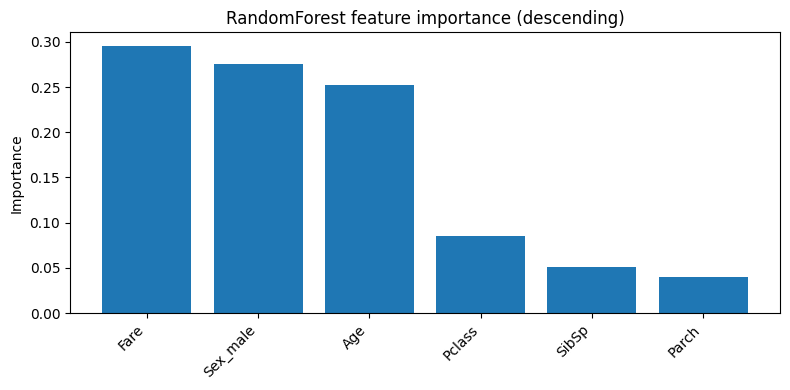

重要度ランキング:
1. Fare      : 0.2957
2. Sex_male  : 0.2754
3. Age       : 0.2522
4. Pclass    : 0.0853
5. SibSp     : 0.0513
6. Parch     : 0.0401


In [21]:
# 各行の「# 説明:」に自分の言葉で意味を書いてください（コードは変更しない）。
# （説明は AI に書かせず、自分で書くこと。rf と X は問題1で作成済み）

importances = rf.feature_importances_       # 説明: 学習済みランダムフォレストが各特徴量に与えた重要度（各特徴量による不純度の減少量の合計を正規化した値）の配列．全特徴量の合計は 1.0．
feature_names = X.columns                   # 説明: 説明変数の列名（Pclass, Age, Fare など）．棒グラフのラベルに使う．

indices = np.argsort(importances)[::-1]     # 説明: argsort は重要度を小さい順に並べたときの「元の位置（添字）」を返す．[::-1] で逆順にして大きい順（降順）の添字にする．

plt.figure(figsize=(8, 4))
plt.bar(range(len(feature_names)), importances[indices])                       # 説明: 降順に並べた重要度（importances[indices]）を棒グラフにする．左ほど重要な特徴量になる．
plt.xticks(range(len(feature_names)), feature_names[indices], rotation=45, ha="right")  # 説明: 横軸の目盛りを，降順に並べた特徴量名にする（rotation=45 で斜めにして重ならないようにする）．
plt.ylabel("Importance")
plt.title("RandomForest feature importance (descending)")
plt.tight_layout()
plt.show()

print("重要度ランキング:")
for rank, i in enumerate(indices, start=1):
    print(f"{rank}. {feature_names[i]:10s}: {importances[i]:.4f}")   # 説明: 順位・特徴量名・重要度を，重要度の高い順に 1 行ずつ表示する（rank は 1 から数える）．


In [22]:
# === ✍️ 問題4 解答（採点対象）===
# 主な提出物は上のコードセルへの # 説明: 記入。以下も記入すること。

# (4-a) `feature_importances_` には何が入っていて、合計はいくつになるか
answer_4_a = """
学習済みランダムフォレストが各特徴量に与えた重要度（その特徴量による分岐で不純度がどれだけ減ったかの合計を、全特徴量で 1 に正規化した値）が特徴量の数だけ入った配列。合計は 1.0。
"""

# (4-b) 設計判断：最も重要だった特徴量（上位2〜3個）
answer_4_b = """
Fare（0.296）、Sex_male（0.275）、Age（0.252）。この 3 つで合計の約 82% を占める。
"""

# (4-c) それが生存予測に効くのはなぜ妥当か
answer_4_c = """
Sex_male：「女性と子どもを優先」した救命ボートの方針で、女性の生存率が男性より大幅に高かったため。Fare と Age：Fare は客室等級・裕福さの代理変数（1 等客室は救命ボートに近い甲板にあった）で、Age は子ども優先のため。ただし Fare と Age は連続値で分岐の候補が多く、重要度が高く出やすい性質もある。
"""

# (4-d) 考察4：相関する特徴量があると重要度はどう歪むか／「重要度が高い＝原因」と言えるか
reflection4 = """
相関する特徴量（Fare と Pclass など）があると、木の分岐でどちらか一方が選ばれやすく、もう一方の重要度が不当に低く出る（重要度が分散する／偏る）。また取りうる値が多い連続変数（Fare, Age）は分岐点の候補が多く、重要度が高く出やすい。「重要度が高い＝原因」とは言えない：重要度は予測への寄与の大きさで、因果ではない（例：Fare が高いことが生存の原因ではなく、客室位置や社会的地位など別の要因の代理）。
"""

